<a href="https://colab.research.google.com/github/sksatvikkumar/DATA110-Cybersecurity-Capstone/blob/main/boston_house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Boston Housing Dataset

![boston-massachusetts-BOSTONTG0221-719aef2eeb1c4929b6c839715e34a69e.jpg](attachment:f616de71-e435-4a62-9bae-a1fe7ccb967d.jpg)



# Description:
                                                               
The Boston Housing dataset contains information about various factors affecting housing prices in the Boston area.

It includes features such as the per capita crime rate, average number of rooms per dwelling,
proportion of residential land zoned for lots over 25,000 square feet, and more.
---------------------------------------------------------
# Columns:

* CRIM: per capita crime rate by town
* ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS: proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: nitric oxides concentration (parts per 10 million)
* RM: average number of rooms per dwelling
* AGE: proportion of owner-occupied units built prior to 1940
* DIS: weighted distances to five Boston employment centres
* RAD: index of accessibility to radial highways
* TAX: full-value property-tax rate per ($10,000)

* PTRATIO: pupil-teacher ratio by town

* B: 1000(Bk - 0.63)^2 where Bk is the proportion of [people of African American descent] by town
* LSTAT: % lower status of the population
* MEDV: Median value of owner-occupied homes in $1000s (target variable)

-----------------------------------------------
# Dataset Source:
The data were derived from information collected by the U.S. Census Service concerning housing in the area of Boston, Massachusetts.

-----------------------------------------
# The Boston Housing Price Prediction
Using Linear Regression , Decision Tree and Random Forest
--

-------------

# Step 1 : Import Libraries

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

import warnings
warnings.filterwarnings('ignore')

---------------------------
# Step 2 : Read the Data


In [ ]:
# Read the data
house = pd.read_csv("Boston (1).csv")
house.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


---------------------------------
# Step 3 : Data Exploration


In [ ]:
# Shape of Data
house.shape

(506, 14)

In [ ]:
# Data information
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
# Checking Null Values
house.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NX         0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [ ]:
# Checking Duplicate Values
house.duplicated().sum()

0

In [ ]:
# Summary of data
house.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


---------------
# Step 4 : Data Visulization


Histogram :  Distribution of Housing Prices
--

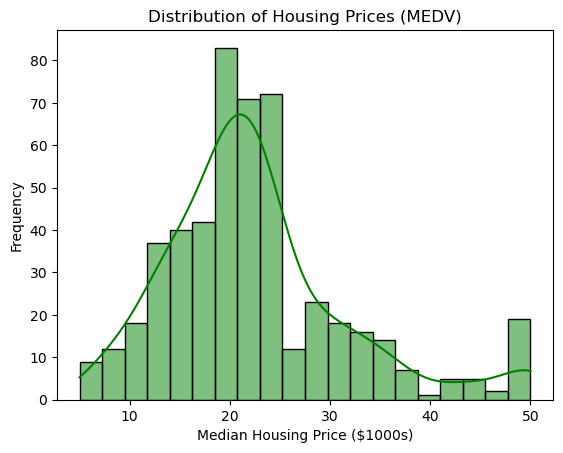

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of Housing Prices (MEDV)

sns.histplot(house['MEDV'], bins=20, kde=True, color='green')
plt.title('Distribution of Housing Prices (MEDV)')
plt.xlabel('Median Housing Price ($1000s)')
plt.ylabel('Frequency')
plt.show()

**Visualize the distribution of median housing prices across different neighborhoods in Boston using histograms. This will help understand the range and distribution of housing prices in the dataset.**

**Obs :-**


* A right-skewed distribution indicates that there are fewer properties with very high prices compared to the number of properties with lower to moderate prices.

*   Prices range from  5,000 to 50,000 (in dollers), indicating a diverse range of property values.



* Quartile analysis offers insights into the distribution across different price ranges.

* Extreme values, like the 50,000(in dollers) maximum, may represent potential outliers.



-----
Boxplot : Distribution of Age of Houses
--



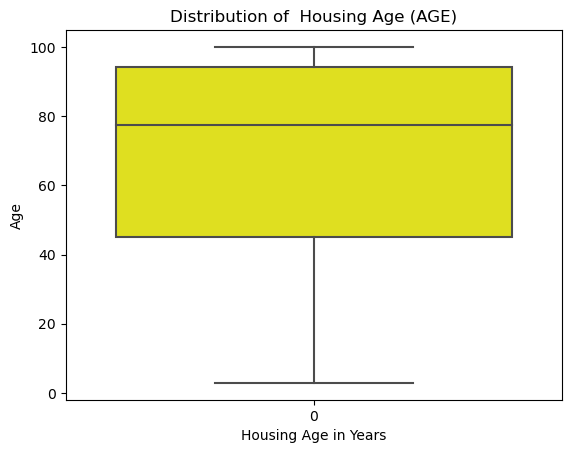

In [ ]:
# Boxplot of Housing Age (AGE)

sns.boxplot(house['AGE'], color='yellow')
plt.title('Distribution of  Housing Age (AGE)')
plt.xlabel('Housing Age in Years')
plt.ylabel('Age')
plt.show()

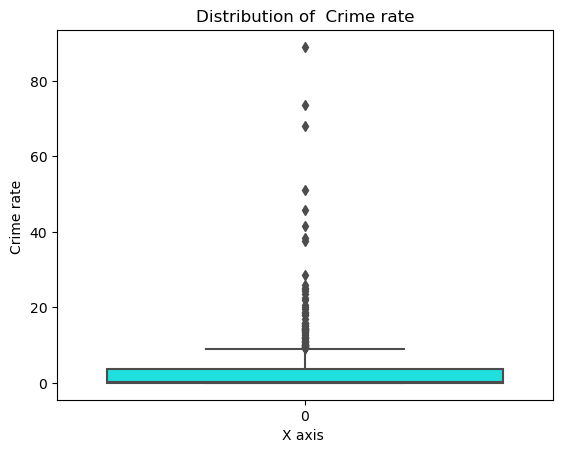

In [ ]:

sns.boxplot(house['CRIM'], color='cyan')
plt.title('Distribution of  Crime rate')
plt.xlabel('X axis ')
plt.ylabel('Crime rate ')
plt.show()

**This visualization provides insights into the variability of housing ages across different areas pf boston.**

**Obs : -**


*   The dataset shows a wide range of property ages, with some properties being relatively new and others significantly older.

*   There's considerable variability in property ages.

*   Property ages range from a minimum of 2.9 years to a maximum of 100 years.

*   Property age can influence maintenance costs and property condition, with older properties potentially requiring more upkeep.


---------------------
**Scatterplot**
--
**1.Rooms per Dwelling (RM) vs. Housing Prices (MEDV)**

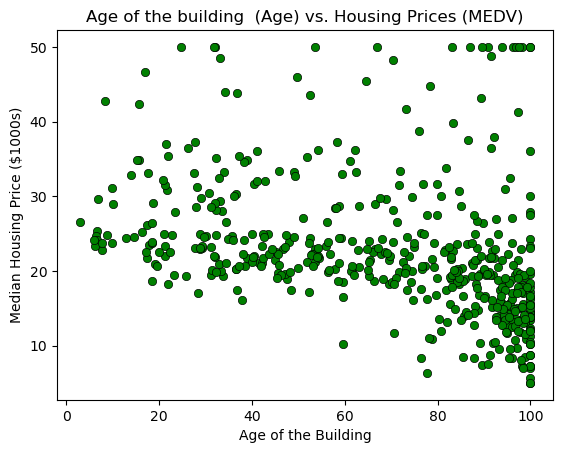

In [ ]:

sns.scatterplot(x='AGE', y='MEDV', data=house, color='green',edgecolor='black', alpha=1)
plt.title('Age of the building  (Age) vs. Housing Prices (MEDV)')
plt.xlabel('Age of the Building')
plt.ylabel('Median Housing Price ($1000s)')
plt.show()

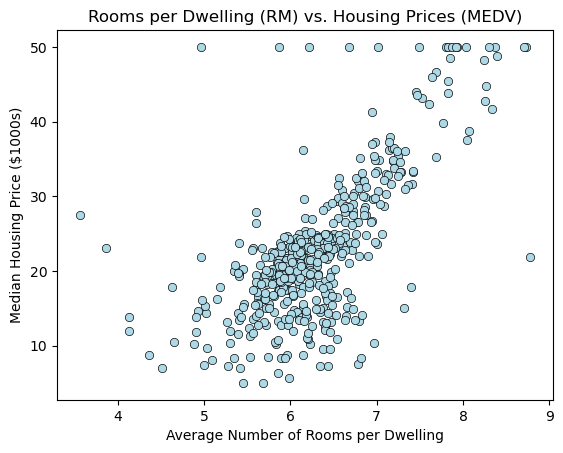

In [ ]:
# Scatter Plot of Rooms per Dwelling (RM) vs. Housing Prices (MEDV)

sns.scatterplot(x='RM', y='MEDV', data=house, color='lightblue',edgecolor='black', alpha=1)
plt.title('Rooms per Dwelling (RM) vs. Housing Prices (MEDV)')
plt.xlabel('Average Number of Rooms per Dwelling')
plt.ylabel('Median Housing Price ($1000s)')
plt.show()

**This scatter plot visualizes the relationship between the average number of rooms per dwelling (RM) and the median housing prices (MEDV) in the dataset. Each point on the plot represents a single observation from the dataset.**

**Obs : -**


*   There appears to be a slightly positive relationship between the number of rooms per dwelling (RM) and housing prices (MEDV).

*   From above chart,we can say that the number of rooms per dwelling is a significant factor in determining housing prices.

------------------
**2.Crime Rate of Housing Area v/s Housing Prices**


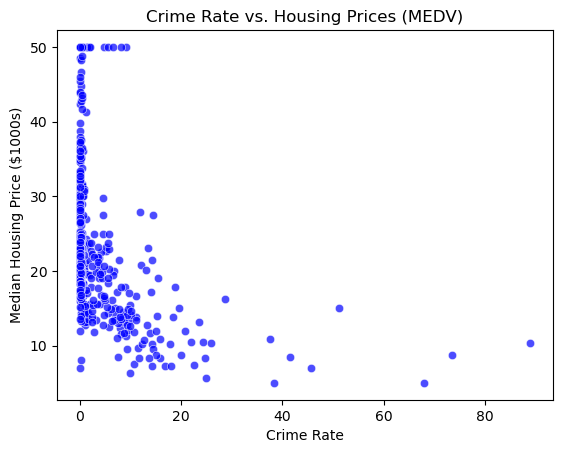

In [ ]:
# Scatter Plot of Crime Rate of Housing Area v/s Housing Prices (MEDV)

sns.scatterplot(x='CRIM', y='MEDV', data=house, color='blue', alpha=0.7)
plt.title('Crime Rate vs. Housing Prices (MEDV)')
plt.xlabel('Crime Rate')
plt.ylabel('Median Housing Price ($1000s)')
plt.show()

**This scatter plot visualizes the relationship between the Crime Rate of area (CRIM) and the median housing prices (MEDV) in the dataset**

**Obs:-**

*   Areas with higher crime rates (CRIM) tend to have lower median housing prices (MEDV), and vice versa.

*    This indicates that crime rate could be a significant factor influencing housing prices in the dataset.

--------------------------------------------------
Barplot : Average Housing prices by Accessibility of Road Highways
--

In [ ]:
rad_medv_mean = house.groupby('RAD')['MEDV'].mean().reset_index()
rad_medv_mean

,RAD,MEDV
0,1,24.365000
1,2,26.833333
2,3,27.928947
3,4,21.387273
4,5,25.706957
5,6,20.976923
6,7,27.105882
7,8,30.358333
8,24,16.403788


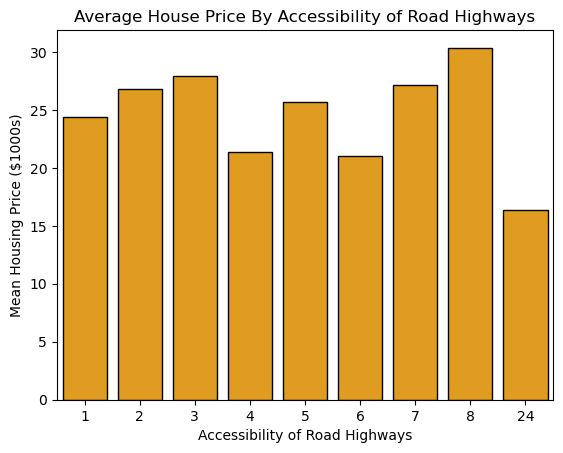

In [ ]:
# Bar Plot Average House Price By Accessibility of Road Highways

sns.barplot(x='RAD', y='MEDV', data=rad_medv_mean, color='orange',edgecolor='black')
plt.title('Average House Price By Accessibility of Road Highways')
plt.xlabel('Accessibility of Road Highways')
plt.ylabel('Mean Housing Price ($1000s)')
plt.show();

**This bar plot illustrates the relationship between the accessibility of road highways (RAD) and the average house price (MEDV) in various neighborhoods.**

**Obs:-**


*   Correlations between RAD (index of accessibility to radial highways) and MEDV could indicate the impact of transportation infrastructure on property values.

*   potential positive relationship between RAD and housing prices



*  There is a notable outlier at RAD=24 where the MEDV is substantially lower compared to the surrounding data points


-----------
Heatmap : Boston Housing Features
--

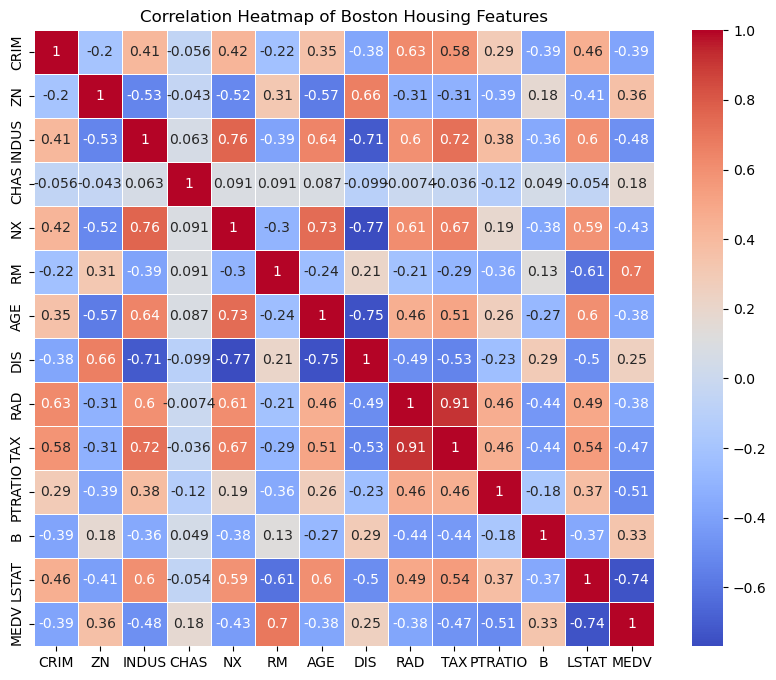

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(house.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Boston Housing Features')
plt.show()

**Heatmap to visualize the correlation matrix of all features in the dataset. This will help identify which features are most strongly correlated with housing prices and with each other.**

**Obs:-**

* Strong positive correlation between the number of rooms (RM) and median housing prices (MEDV).
* Strong negative correlation between the percentage of lower status population (LSTAT) and median housing prices.


* Moderate negative correlations between industrial land proportion (INDUS) and pupil-teacher ratio (PTRATIO) with median housing prices.


* Weak negative correlation between crime rate (CRIM) and median housing prices.
* Weak positive correlation between properties along the Charles River (CHAS) and median housing prices.


* Potential multicollinearity between accessibility to radial highways (RAD) and property-tax rate (TAX).

------------------
# Step 5 : Split the Data

In [ ]:
# Split the Data
X = house.drop(columns=['MEDV']) #features
y = house['MEDV'] #target variable

In [ ]:
# Splitting Data for Train and Test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3)

In [ ]:
# shape of spiltted data
print("The shape of X_train :",X_train.shape)
print("The shape ofX_test :",X_test.shape)
print("The shape of y_train :",y_train.shape)
print("The shape of y_test :",y_test.shape)

The shape of X_train : (354, 13)
The shape ofX_test : (152, 13)
The shape of y_train : (354,)
The shape of y_test : (152,)


# Step 6 : Train the Model

-------------------------
Linear Regression
--

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
# Fit the model on Training dataset
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
# # Predictions of Linear Regressoion on Testing Data
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

# Accuracy Score of Model
from sklearn.metrics import mean_absolute_percentage_error
error = mean_absolute_percentage_error(y_pred_lr,y_test)
print("Accuracy of Linear Regression is :%.2f "%((1 - error)*100),'%')

Accuracy of Linear Regression is :77.95  %


----------------------------------
Decision Tree Regressor
--

In [ ]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(max_depth=5)

In [ ]:
# Fit the model on Training dataset
dtr.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5)

In [ ]:
# Predictions of  decision Tree Regressor on Testing Data
y_pred_dtr=dtr.predict(X_test)

In [ ]:
# Accuracy Score of Model

error = mean_absolute_percentage_error(y_pred_dtr,y_test)
print("Accuracy of Decision Tree Regressor is :%.2f "%((1 - error)*100),'%')

Accuracy of Decision Tree Regressor is :87.88  %


--------------------------------
Random Forest Regressor
--

In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()

In [ ]:
# Fit the model on Training datset
rfr.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
# Predictions of  Ranforest Forest Regressor on Testing Data
y_pred_rfr = rfr.predict(X_test)

In [ ]:
# Accuracy Score of Model

error = mean_absolute_percentage_error(y_pred_rfr,y_test)
print("Accuracy of Random Forest Regressor is :%.2f "%((1 - error)*100),'%')

# Best Model
Random Forest Regressor:
--
* **Accuracy**: 89.83%
* **Pros**: Ensemble of decision trees reduces overfitting, robust to noise and outliers, handles high-dimensional data well.

* **In this scenario, since Random Forest Regressor has the highest accuracy, it might be considered the best model for making predictions on the given dataset.**

-----------------------------------------------------------THE END------------------------------------------------------------------------
### **Thank You for Exploring My Notebook!**

I hope you found this notebook informative and helpful in your data science journey. Your feedback is highly appreciated!

If you enjoyed this notebook or found it helpful, please consider upvoting it. Your support motivates me to create more content and improve the quality of my work.

Additionally, if you have any suggestions, questions, or ideas for improvement, please feel free to leave a comment. I value your input and would love to hear from you!

Happy learning, and thank you for your support!
